In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

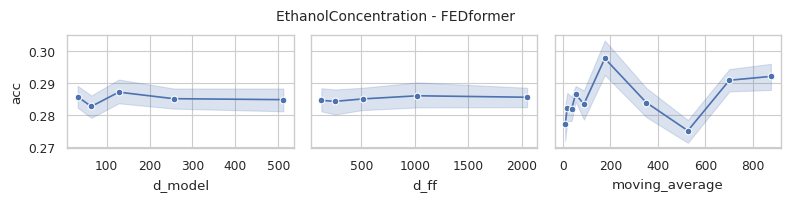

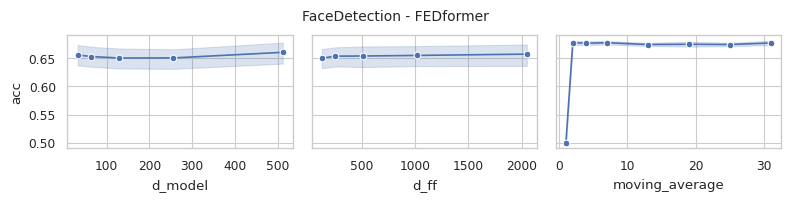

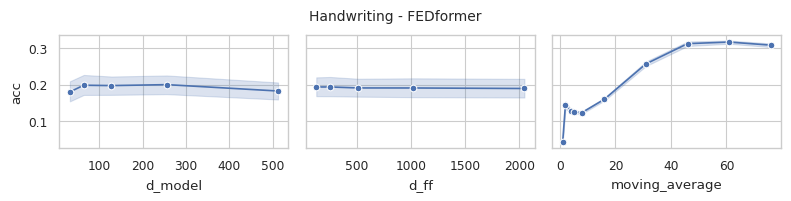

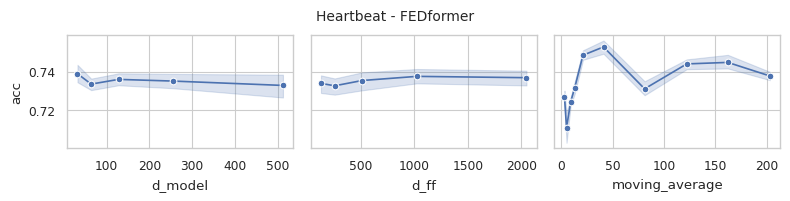

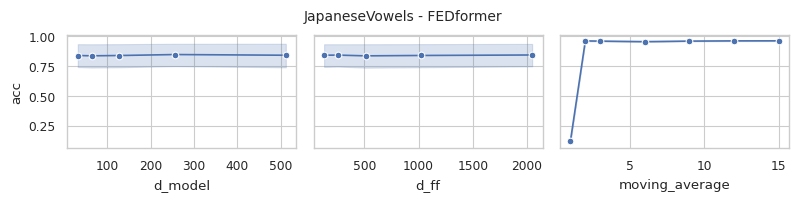

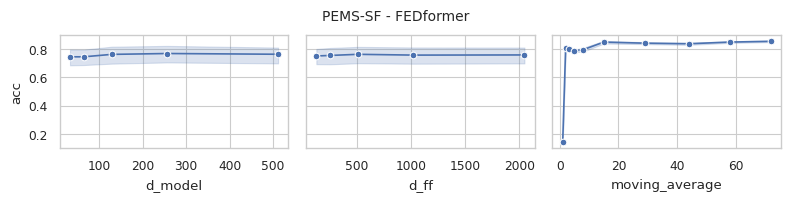

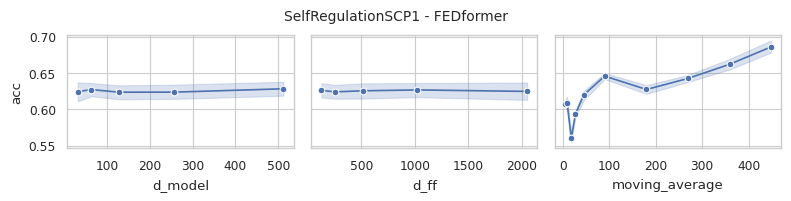

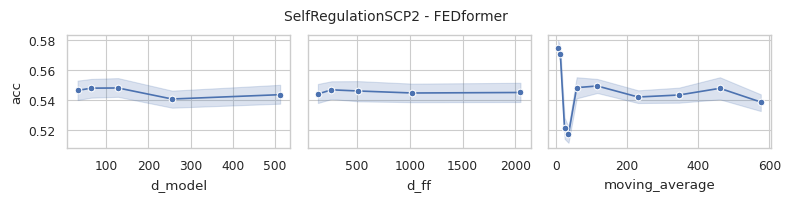

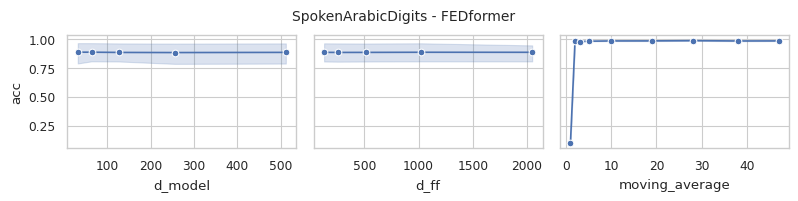

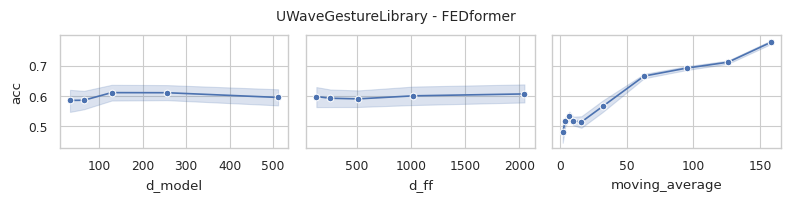

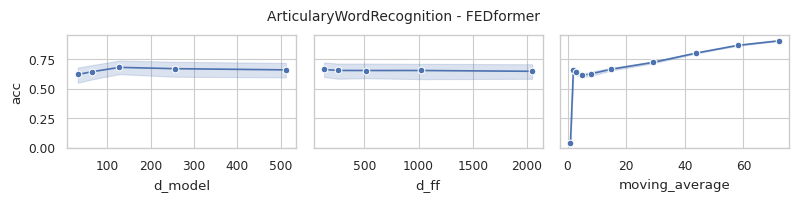

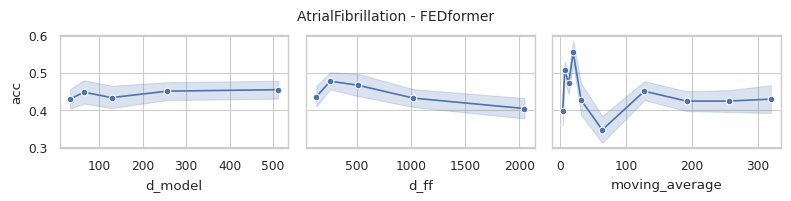

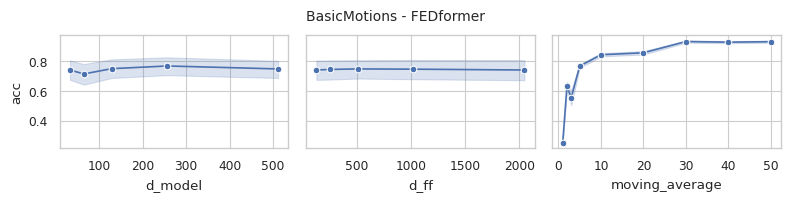

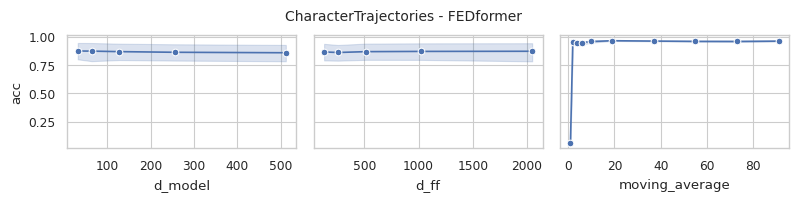

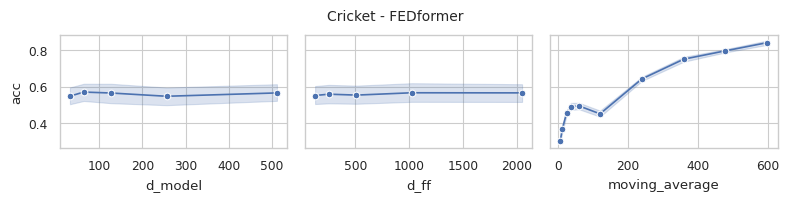

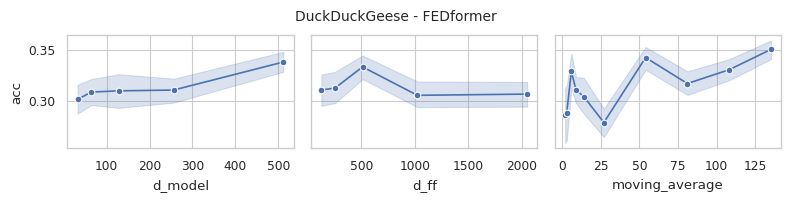

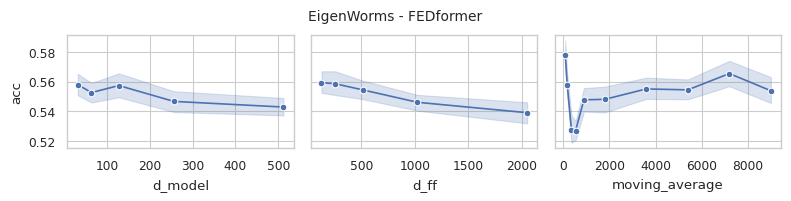

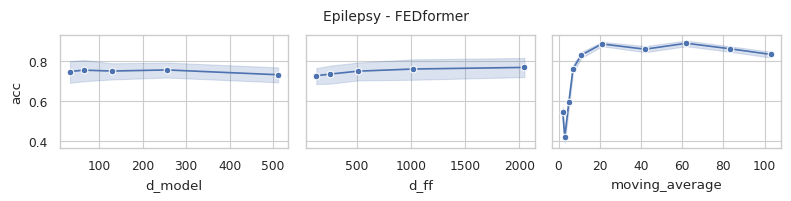

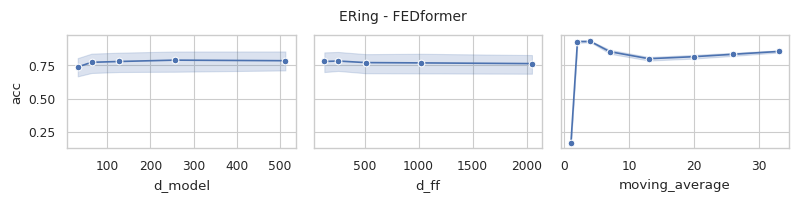

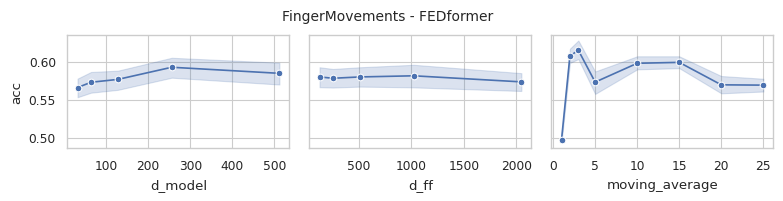

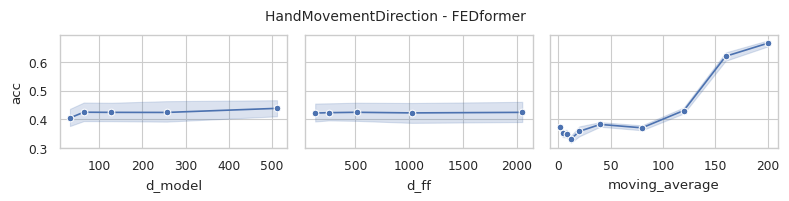

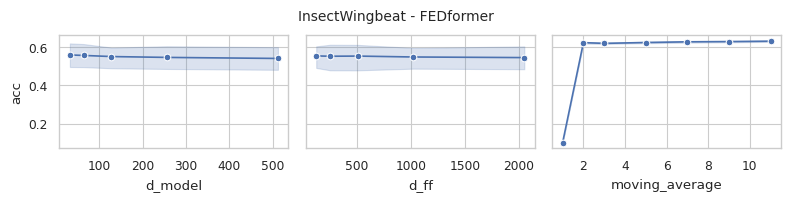

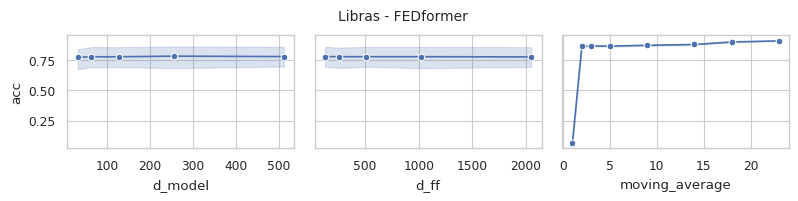

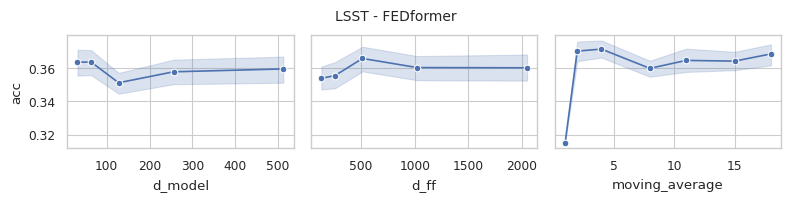

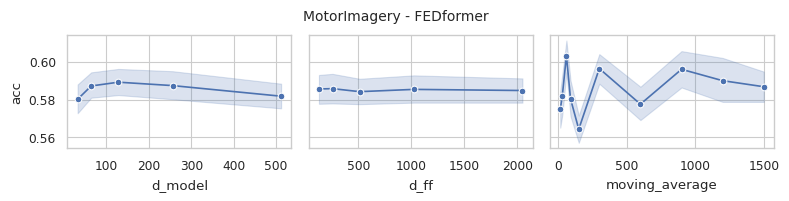

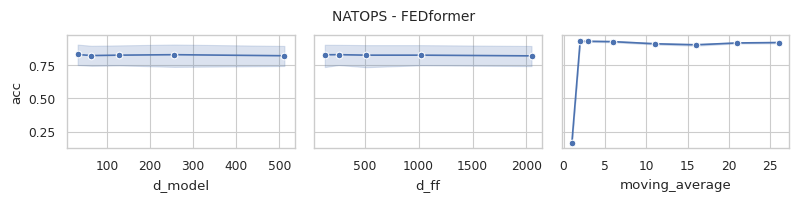

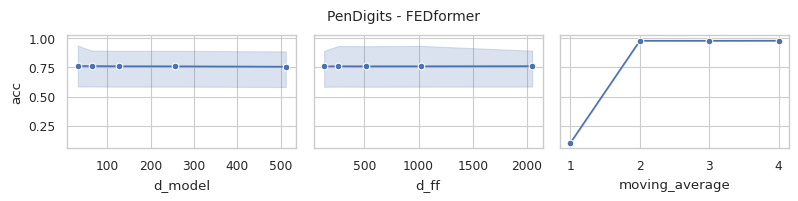

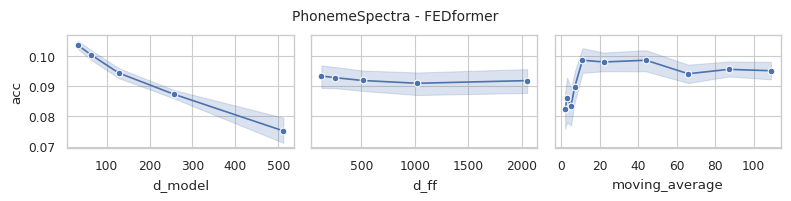

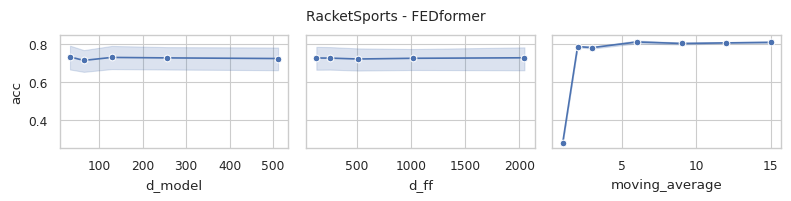

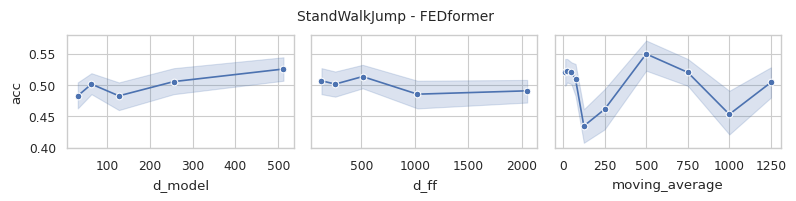

In [4]:
model = 'FEDformer'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('dm', ''))
            data_meta[10] = int(data_meta[10].replace('nh', ''))
            data_meta[11] = int(data_meta[11].replace('el', ''))
            data_meta[12] = int(data_meta[12].replace('dl', ''))
            data_meta[13] = int(data_meta[13].replace('df', ''))
            data_meta[14] = int(data_meta[14].replace('ma', ''))
            # data_meta[15] = data_meta[15].replace('exp', '')
            # data_meta[16] = data_meta[16].replace('desc', '')

            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'task_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'd_model': data_meta[9],
                'n_heads': data_meta[10],
                'e_layers': data_meta[11],
                'd_layers': data_meta[12],
                'd_ff': data_meta[13],
                'moving_average': data_meta[14],
                # 'exp': data_meta[15],
                # 'desc': data_meta[16],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['d_model', 'd_ff', 'moving_average']
    num_cols, num_rows = 3, 1
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False, style='model', markers=True)
    for i in range(len(cols), num_cols*num_rows):
        fig.delaxes(axs[i%num_cols])
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    
    

In [5]:
model_configs = {
    "moving_avg_ratio" : [0.5, 1, 2, 3, 5, 10, 20, 30, 40, 50],  
    "e_layers" : [2],
    "n_heads" : [8],
    "d_model" : [32,64,128,256,512],
    "d_ff" : [128,256,512,1024,2048],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        e_layers = hyperparameter_combination['e_layers']
        d_model = hyperparameter_combination['d_model']
        n_heads = hyperparameter_combination['n_heads']
        d_ff = hyperparameter_combination['d_ff']
        ma_ratio = hyperparameter_combination['moving_avg_ratio']
        ma_window = math.ceil(seq_len * ma_ratio / 100)
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['e_layers'] == e_layers)
                & (tmp['d_model'] == d_model)
                & (tmp['n_heads'] == n_heads)
                & (tmp['d_ff'] == d_ff)
                & (tmp['moving_average'] == ma_window)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 128}","{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 32, 'd_ff': 512}","{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 512}","{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 512, 'd_ff': 512}","{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 128, 'd_ff': 128}","{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 32, 'd_ff': 256}","{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 512, 'd_ff': 1024}","{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 128, 'd_ff': 256}","{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 256, 'd_ff': 128}",...,"{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 128}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 128, 'd_ff': 256}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 32, 'd_ff': 1024}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 2048}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 32, 'd_ff': 256}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 32, 'd_ff': 512}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 512, 'd_ff': 2048}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 1024}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 32, 'd_ff': 2048}","{'moving_avg_ratio': 0.5, 'e_layers': 2, 'n_heads': 8, 'd_model': 32, 'd_ff': 128}"
EthanolConcentration,0.338403,0.281369,0.311787,0.285171,0.292776,0.269962,0.277567,0.311787,0.296578,0.288973,...,0.269962,0.277567,0.26616,0.254753,0.273764,0.281369,0.281369,0.273764,0.26616,0.262357
FaceDetection,0.698922,0.669977,0.678207,0.67622,0.695233,0.684733,0.686152,0.692111,0.67168,0.665437,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
Handwriting,0.334118,0.309412,0.298824,0.331765,0.297647,0.305882,0.309412,0.308235,0.317647,0.316471,...,0.050588,0.042353,0.043529,0.050588,0.037647,0.050588,0.042353,0.050588,0.037647,0.04
Heartbeat,0.780488,0.731707,0.741463,0.731707,0.736585,0.736585,0.741463,0.741463,0.736585,0.741463,...,0.726829,0.721951,0.721951,0.741463,0.717073,0.717073,0.736585,0.721951,0.712195,0.726829
JapaneseVowels,0.975676,0.967568,0.962162,0.962162,0.959459,0.967568,0.972973,0.964865,0.967568,0.962162,...,0.118919,0.094595,0.135135,0.135135,0.118919,0.118919,0.083784,0.078378,0.118919,0.108108
PEMS-SF,0.890173,0.83815,0.843931,0.861272,0.855491,0.867052,0.849711,0.855491,0.820809,0.867052,...,0.156069,0.127168,0.115607,0.156069,0.127168,0.115607,0.17341,0.156069,0.150289,0.132948
SelfRegulationSCP1,0.750853,0.672355,0.699659,0.679181,0.686007,0.686007,0.699659,0.696246,0.672355,0.679181,...,0.617747,0.607509,0.607509,0.59727,0.604096,0.600683,0.59727,0.614334,0.59727,0.617747
SelfRegulationSCP2,0.594444,0.566667,0.555556,0.544444,0.544444,0.533333,0.555556,0.522222,0.555556,0.522222,...,0.583333,0.588889,0.555556,0.577778,0.561111,0.588889,0.572222,0.572222,0.572222,0.566667
SpokenArabicDigits,0.994543,0.992724,0.988631,0.989086,0.974989,0.988176,0.986812,0.982265,0.983629,0.974989,...,0.100045,0.100045,0.100045,0.100045,0.100045,0.100045,0.100045,0.100045,0.100045,0.100045
UWaveGestureLibrary,0.796875,0.775,0.771875,0.78125,0.746875,0.765625,0.784375,0.753125,0.784375,0.759375,...,0.49375,0.45625,0.3875,0.475,0.43125,0.43125,0.490625,0.475,0.409375,0.15


In [7]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'moving_avg_ratio': 50, 'e_layers': 2, 'n_heads': 8, 'd_model': 64, 'd_ff': 128}"
EthanolConcentration,33.84030418250951,28.13688212927757
FaceDetection,69.8921679909194,66.99772985244041
Handwriting,33.41176470588236,30.94117647058823
Heartbeat,78.04878048780488,73.17073170731707
JapaneseVowels,97.56756756756756,96.75675675675676
PEMS-SF,89.01734104046243,83.8150289017341
SelfRegulationSCP1,75.0853242320819,67.23549488054607
SelfRegulationSCP2,59.44444444444444,56.66666666666666
SpokenArabicDigits,99.45429740791269,99.27239654388357
UWaveGestureLibrary,79.6875,77.5
